# Ray tracing simulation # 

In [19]:
import os, importlib
import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial

import sionna
from importlib.metadata import version
print("Sionna version:", version("sionna"))

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import util
import plot


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']
Sionna version: 2.0.0


In [20]:
# Import scene as xml file
scene = load_scene("SimpleConfig/SimpleConfig.xml")

scene.radio_materials["itu-concrete"].thickness = 0.2

# print("Available materials:", scene.radio_materials.keys())
# mat = scene.radio_materials["itu-concrete"]
# print(f"Material: {mat.name}")
# print(f"Conductivity: {mat.conductivity.numpy()} S/m")
# print(f"Relative Permittivity: {mat.relative_permittivity.numpy()}")
# print(f"Thickness: {mat.thickness.numpy()} m")

ground = ITURadioMaterial("ground",
                        "concrete",
                        thickness=1,
                        color=[0.011, 0.27, 0.8])

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

ground_object = scene.objects["elm__7"]
ground_object.radio_material = ground

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')
num_rx_ant = 4
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=num_rx_ant,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')

print(scene.rx_array.antenna_pattern.compute_gain())
print(scene.rx_array.positions(3e8/3.5e9))

# Tx position
TX_position = [3, 0, 1.5]

tx = Transmitter("tx", TX_position)
scene.add(tx)

# Rx positions
RX_positions = [[-7, 8, 1.5], 
                [0, 8, 1.5], 
                [7, 8, 1.5], 
                [9, 0, 1.5], 
                [-9, 0, 1.5], 
                [-7, -8, 1.5], 
                [0, -8, 1.5], 
                [7, -8, 1.5]]

RX_orientations = [[-np.pi/4, 0, 0], 
                   [-np.pi/2, 0, 0], 
                   [-3*np.pi/4, 0, 0], 
                   [np.pi, 0, 0], 
                   [0, 0, 0], 
                   [np.pi/4, 0, 0], 
                   [np.pi/2, 0, 0], 
                   [3*np.pi/4, 0, 0]]

rx1 = Receiver("rx", RX_positions[0], RX_orientations[0])
rx2 = Receiver("rx2", RX_positions[1], RX_orientations[1])
rx3 = Receiver("rx3", RX_positions[2], RX_orientations[2])
rx4 = Receiver("rx4", RX_positions[3], RX_orientations[3])
rx5 = Receiver("rx5", RX_positions[4], RX_orientations[4])
rx6 = Receiver("rx6", RX_positions[5], RX_orientations[5])
rx7 = Receiver("rx7", RX_positions[6], RX_orientations[6])
rx8 = Receiver("rx8", RX_positions[7], RX_orientations[7])
scene.add(rx1)
scene.add(rx2)
scene.add(rx3)
scene.add(rx4)
scene.add(rx5)
scene.add(rx6)
scene.add(rx7)
scene.add(rx8)

scene.preview()

no-name-2      itu-concrete
elm__7         itu-glass
Directivity [dB]: 1.76
Gain [dB]: 1.76
Efficiency [%]: 1e+02
([1.49999], [1.5], [1.00001])
[[0, -0.0642857, 0],
 [0, -0.0214286, 0],
 [0, 0.0214286, 0],
 [0, 0.0642857, 0]]


In [21]:
### System parameters ###

# Band sampling parameters
B = 100e6
T = 1 / B
osr = 8
Fs = B * osr
Ts = 1 / Fs

# Transmit power
P_TX_dBm = 0
P_TX_lin = 10 ** (P_TX_dBm / 10) / 1000

S_RX_dBm = -90
S_RX_lin = 10 ** (S_RX_dBm / 10) / 1000

### Paths computations ###

In [22]:
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=15)

# 1. Get current valid mask to know the correct shape
# This is crucial: 'valid' might have fewer dimensions than 'a'
original_valid_np = paths.valid.numpy()
target_shape = original_valid_np.shape

# 2. Get signal magnitude from 'a'
a_r, a_i = paths.a
a_r_np, a_i_np = a_r.numpy(), a_i.numpy()
magnitudes = np.sqrt(a_r_np**2 + a_i_np**2)

# 3. Reduce magnitude to match 'valid' shape
# If 'a' has extra antenna dimensions (dims 1 and 3), max over them
# Example: Convert [Rx, RxAnt, Tx, TxAnt, Paths] -> [Rx, Tx, Paths]
if len(magnitudes.shape) > len(target_shape):
    # Reduce dimensions 1 and 3 (antenna arrays) by taking the max power across antennas
    # Adjust axes based on your actual shape. Typically:
    # Axis 0=Rx, 1=RxAnt, 2=Tx, 3=TxAnt, 4=Paths
    reduced_magnitudes = np.max(magnitudes, axis=(1, 3)) 
else:
    reduced_magnitudes = magnitudes

# 4. Create the filter mask
# Keep paths where power is > 5% of peak
keep_mask = np.zeros(target_shape, dtype=bool)

# Iterate over Rx/Tx pairs to calculate local thresholds
for i in range(target_shape[0]): # Rx
    for j in range(target_shape[1]): # Tx
        # Get all paths for this link
        path_powers = reduced_magnitudes[i, j, :]
        max_val = np.max(path_powers)
        
        if max_val > 0:
            # Create boolean filter
            keep_mask[i, j, :] = path_powers >= (0.5 * max_val)

# 5. Combine with original validity (Logical AND)
# This ensures we don't accidentally "revive" non-existent paths
final_mask = keep_mask & original_valid_np

# 6. Apply to the internal _valid variable
# Use TensorXb (Extended Boolean Tensor)
paths._valid = mi.TensorXb(final_mask)

# 7. (Optional) Zero out 'a' for consistency
# You might need to broadcast the mask back to 'a's shape if they differ
paths._a = (
    mi.TensorXf(a_r_np * final_mask[:, None, :, None, :]), # Broadcast if needed
    mi.TensorXf(a_i_np * final_mask[:, None, :, None, :])
)


In [23]:
scene.preview(paths=paths)

[0.         0.3469289  0.69385768 1.04078653]
[-0.          1.10308927  2.20617854 -2.97391754]
[4.79516439e-17 9.93466358e-01 1.98693236e+00 2.98039869e+00]
[5.65135795e-17 5.65135795e-17 5.65135795e-17 5.65135795e-17]
[-0. -0. -0. -0.]
[-0.         -0.3469289  -0.69385765 -1.04078654]
[ 0.         -1.10308925 -2.2061785   2.97391759]
[ 0.         -0.20897086 -0.41794171 -0.62691249]


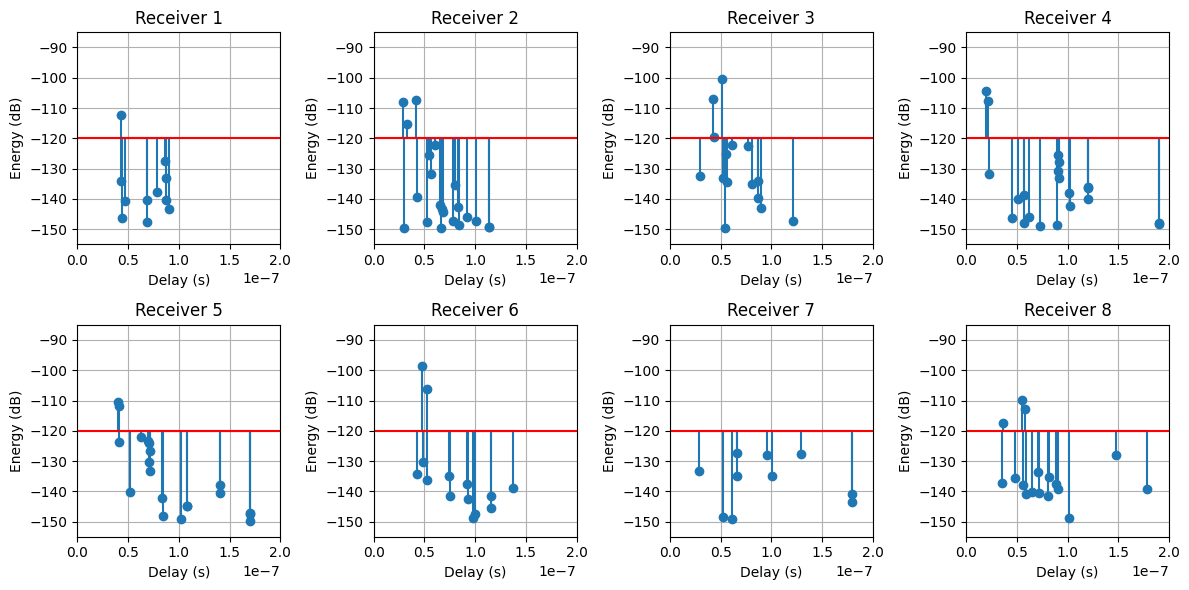

In [24]:
importlib.reload(util)

# Channel impulse response of the path
cir = paths.cir(sampling_frequency=3.5e9,
                num_time_steps=1,
                normalize_delays=False)

angles = paths.phi_r

a, tau, angles = util.format_paths(cir, angles, array=True)

# Scale a with transmit power
a = [a_i * np.sqrt(P_TX_lin) for a_i in a]

for i in range(len(a)):
    print(np.angle(a[i][:, 0] / a[i][0, 0]))

# Energy of paths
magnitudes = [np.abs(a[i]) for i in range(8)]
energies = [magnitudes[i]**2 for i in range(8)]


# Filter paths too weak
threshold = -150 # in dB, relative to P_TX
threshold_lin = 10 ** (threshold / 10)

for i in range(8):
    mask = energies[i] >= threshold_lin
    a[i] = a[i][mask].reshape(num_rx_ant, -1)
    tau[i] = tau[i][mask[0]]
    angles[i] = angles[i][mask[0]]
    magnitudes[i] = magnitudes[i][mask].reshape(num_rx_ant, -1)
    energies[i] = energies[i][mask].reshape(num_rx_ant, -1)


plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.stem(tau[i], 10*np.log10(energies[i][0]), bottom=10*np.log10(S_RX_lin))
    plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.xlim(0, 2e-7)
    plt.ylim(-155, -85)
    plt.grid()
plt.tight_layout()

2.6335173750178045e-11
2.3908736536642843e-11


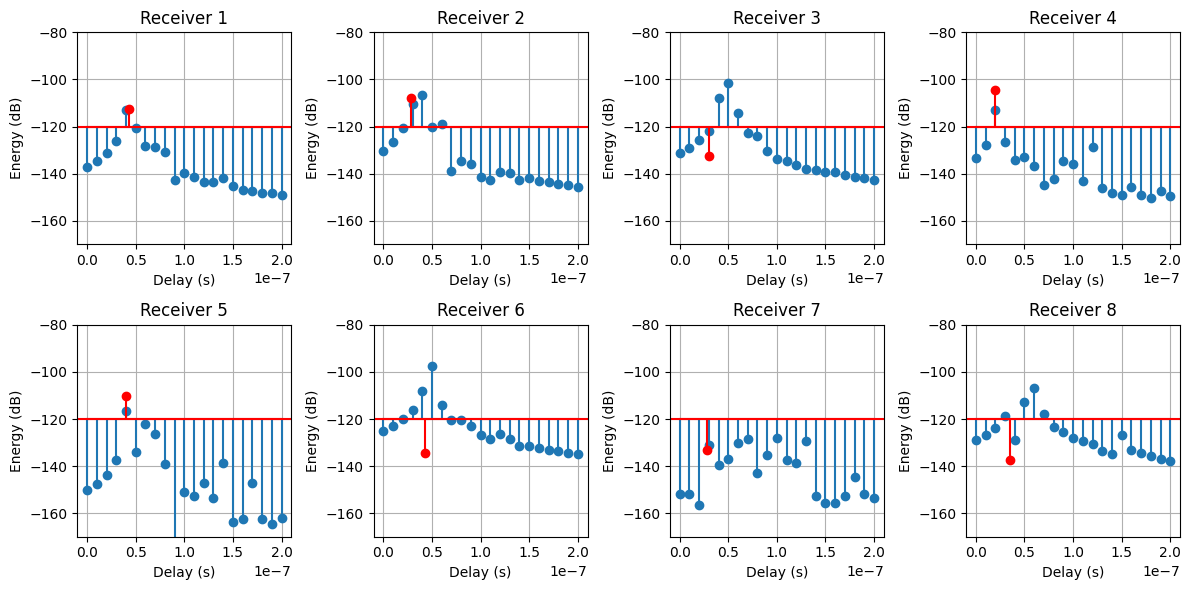

In [25]:
# Channel impulse response of the path
l_min, l_max = 0, 20
t = np.arange(l_min, l_max+1) / B

taps = paths.taps(bandwidth=B, l_min=l_min, l_max=l_max, normalize_delays=False)
taps_re, taps_im = taps[0], taps[1]
taps_re = taps_re.numpy().reshape(taps_re.shape[0], num_rx_ant, -1) * np.sqrt(P_TX_lin)
taps_im = taps_im.numpy().reshape(taps_im.shape[0], num_rx_ant, -1) * np.sqrt(P_TX_lin)
taps_lin = taps_re + 1j * taps_im
taps_mag = np.sqrt(taps_re**2 + taps_im**2)
taps_energy = taps_mag ** 2


print(np.sum(taps_energy[0]))
print(np.sum(energies[0]))


plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.stem(t, 10*np.log10(taps_energy[i][0]), bottom=10*np.log10(S_RX_lin))
    plt.stem(tau[i][0], 10*np.log10(energies[i][0][0]), bottom=10*np.log10(S_RX_lin), linefmt='r-', markerfmt='ro', label='Path Energies')
    plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.xlim((l_min-1)/B, (l_max+1)/B)
    plt.ylim(-170, -80)
    plt.grid()
plt.tight_layout()

In [26]:
import Multipath as mp
import Comm as com
importlib.reload(mp)
importlib.reload(com)


fft_size = 256
RX_idx = 3
music_spectrum, music_tau, music_angles, K, estimated_channel = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
# music_a, music_taus = mp.MUSIC_taps_time(music_spectrum, music_tau, B/fft_size, estimated_channel)


R shape: (512, 512)
Optimal number of paths: 4
Eigenvalues around the threshold: [7.06749573e-11 4.93776634e-11 3.31887989e-11 1.32190434e-11
 1.16282081e-11 1.10226437e-11 1.07387051e-11 1.04715525e-11]


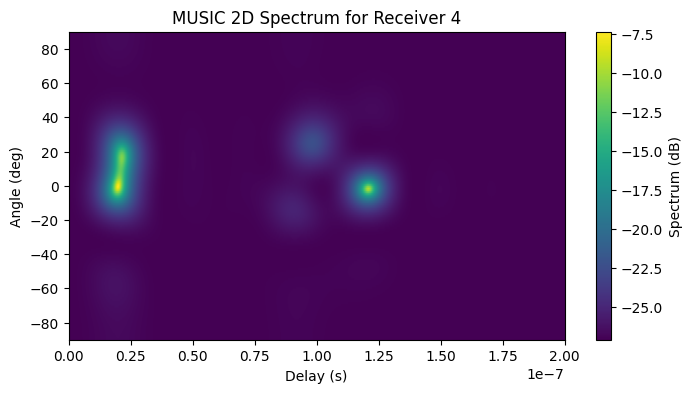

In [27]:
local_angles = util.format_local_angles(angles, RX_orientations)

plt.figure(figsize=(8, 4))
plt.imshow(10*np.log10(music_spectrum.T), extent=(music_tau[0], music_tau[-1], music_angles[0]*180/np.pi, music_angles[-1]*180/np.pi), aspect='auto', origin='lower')
# plt.scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
plt.title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
plt.xlabel("Delay (s)")
plt.ylabel("Angle (deg)")
plt.colorbar(label='Spectrum (dB)')
plt.show()

Optimal number of paths: 2


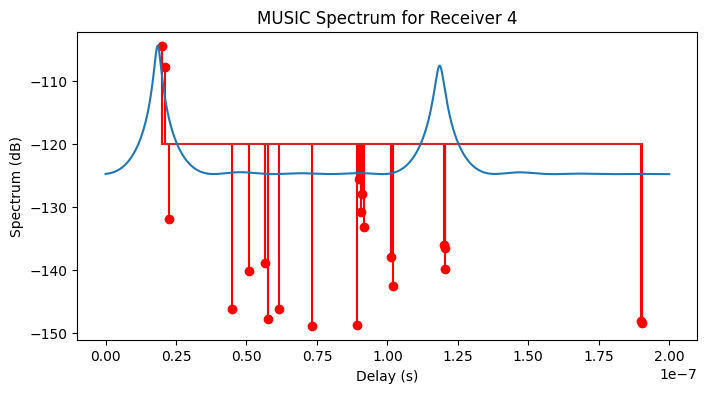

In [28]:
importlib.reload(mp)
importlib.reload(com)

music_spectrum, music_tau, K, estimated_channel = mp.MUSIC_spectrum(a[RX_idx][0], tau[RX_idx], B, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)

plt.figure(figsize=(8, 4))
plt.stem(tau[RX_idx], 10*np.log10(energies[RX_idx][0]), markerfmt='ro', linefmt='r-', label='True Path Energies', bottom=10*np.log10(S_RX_lin))
plt.plot(music_tau, 10*np.log10(music_spectrum*np.max(energies[RX_idx][0])/np.max(music_spectrum)), label='MUSIC Spectrum')
plt.title(f"MUSIC Spectrum for Receiver {RX_idx+1}")
plt.xlabel("Delay (s)")
plt.ylabel("Spectrum (dB)")
plt.show()

In [29]:
importlib.reload(mp)
importlib.reload(com)

music_spectrums = []
music_taus = []
music_angles_list = []
music_K_list = []
music_h_hats = []
for RX_idx in range(8):
    music_spectrum, music_tau, music_angles, music_K, music_h_hat = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
    music_spectrums.append(music_spectrum)
    music_taus.append(music_tau)
    music_angles_list.append(music_angles)
    music_K_list.append(music_K)
    music_h_hats.append(music_h_hat)

R shape: (512, 512)
Optimal number of paths: 2
Eigenvalues around the threshold: []
R shape: (512, 512)
Optimal number of paths: 4
Eigenvalues around the threshold: [4.67385766e-09 4.07887684e-10 3.46191764e-11 1.57765868e-11
 1.16855701e-11 1.10568845e-11 1.05028998e-11 1.02286008e-11]
R shape: (512, 512)
Optimal number of paths: 4
Eigenvalues around the threshold: [3.61808778e-09 3.54193672e-10 6.47240240e-11 1.11601136e-11
 1.11302590e-11 1.08372985e-11 1.07173724e-11 1.03542598e-11]
R shape: (512, 512)
Optimal number of paths: 4
Eigenvalues around the threshold: [8.01785642e-11 5.03963156e-11 2.63860967e-11 1.64486217e-11
 1.18357283e-11 1.05553280e-11 1.04606555e-11 1.03717389e-11]
R shape: (512, 512)
Optimal number of paths: 3
Eigenvalues around the threshold: [1.81984943e-09 3.82896299e-10 4.85243773e-11 1.80659393e-11
 1.14133651e-11 1.09162727e-11 1.07927450e-11 1.06263053e-11]
R shape: (512, 512)
Optimal number of paths: 4
Eigenvalues around the threshold: [5.58839128e-10 3.7

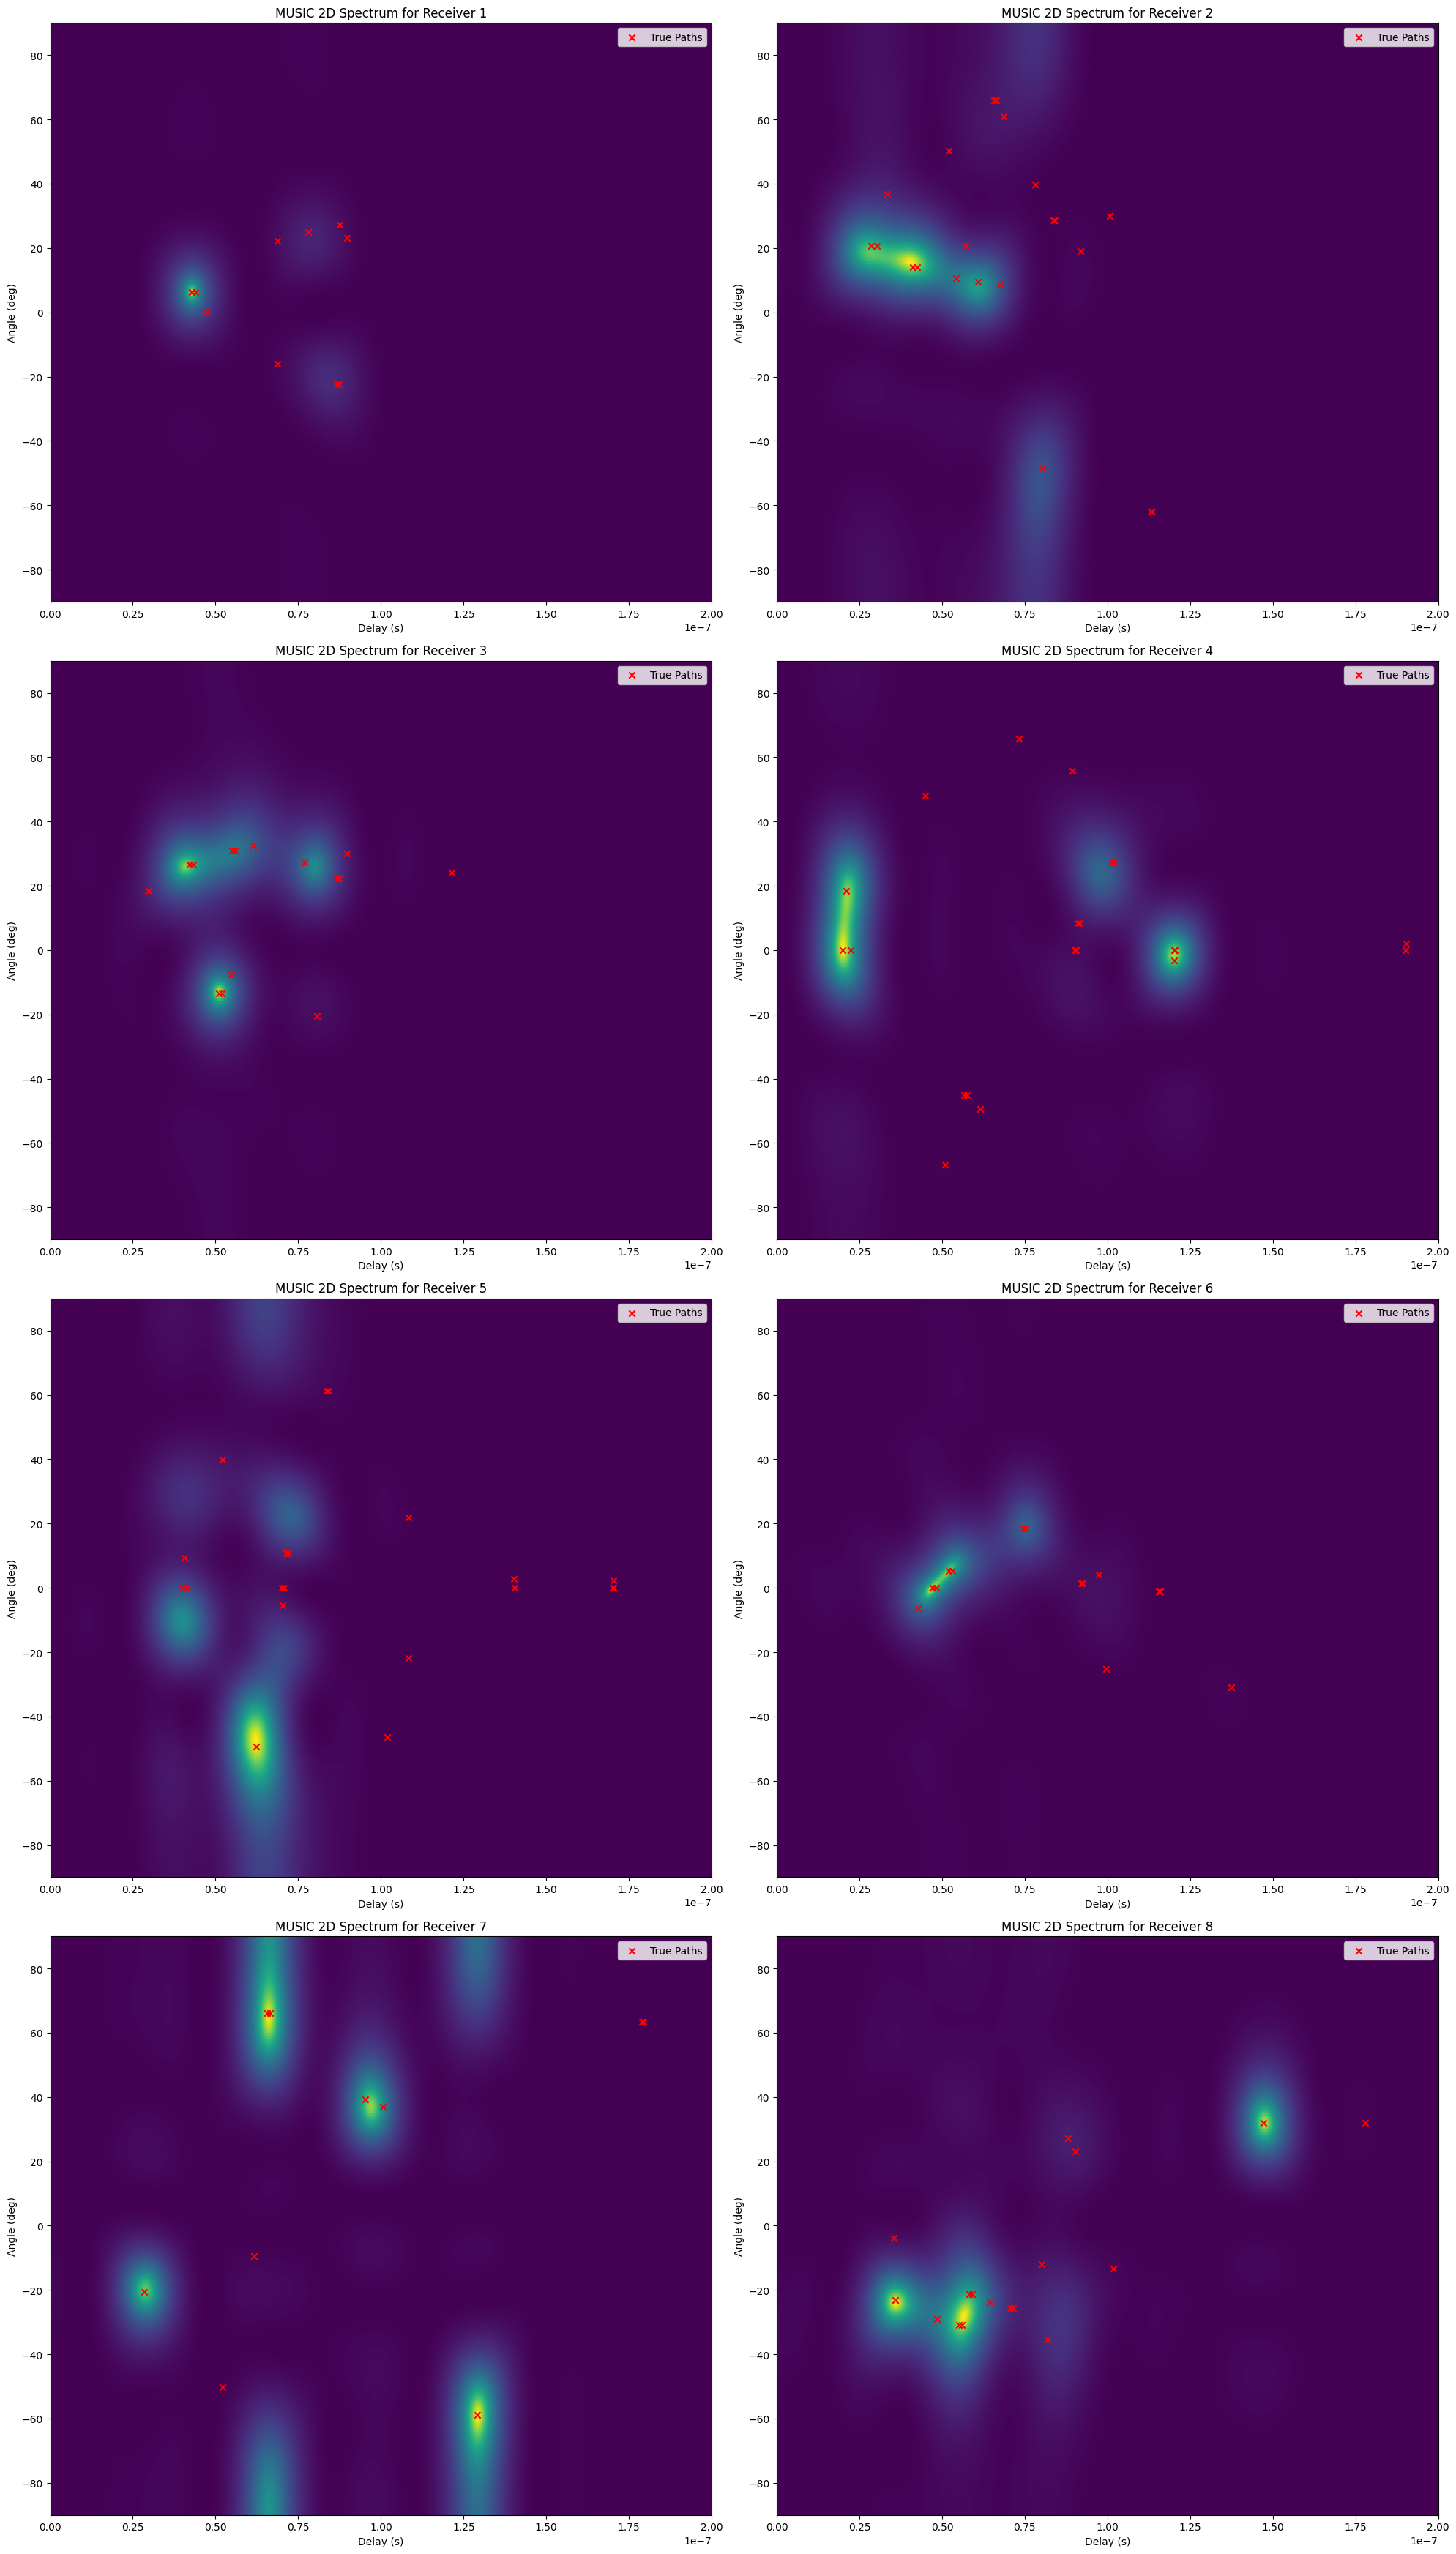

In [30]:
fig, ax = plt.subplots(4, 2, figsize=(20, 35))
for RX_idx in range(8):
    ax[RX_idx//2, RX_idx%2].imshow(10*np.log10(music_spectrums[RX_idx].T), extent=(music_taus[RX_idx][0], music_taus[RX_idx][-1], music_angles_list[RX_idx][0]*180/np.pi, music_angles_list[RX_idx][-1]*180/np.pi), aspect='auto', origin='lower')
    ax[RX_idx//2, RX_idx%2].scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
    ax[RX_idx//2, RX_idx%2].set_title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
    ax[RX_idx//2, RX_idx%2].set_xlabel("Delay (s)")
    ax[RX_idx//2, RX_idx%2].set_ylabel("Angle (deg)")
    ax[RX_idx//2, RX_idx%2].legend()
plt.tight_layout()
plt.show()

In [31]:
importlib.reload(mp)

music_taps_list = []
music_estimated_taus_list = []
music_estimated_angles_list = []
print(music_spectrums[0].shape)
for RX_idx in range(8):
    music_taps, music_estimated_taus, music_estimated_angles = mp.MUSIC_2D_taps(music_spectrums[RX_idx], 
                                                                                music_taus[RX_idx], 
                                                                                music_angles_list[RX_idx], 
                                                                                B/fft_size, 
                                                                                music_K_list[RX_idx], 
                                                                                music_h_hats[RX_idx])
    music_taps_list.append(music_taps)
    music_estimated_taus_list.append(music_estimated_taus)
    music_estimated_angles_list.append(music_estimated_angles)
    print(music_estimated_taus)



(1000, 180)
[4.26426426e-08 8.40840841e-08]
[2.84284284e-08 4.04404404e-08 6.04604605e-08 7.94794795e-08]
[4.08408408e-08 5.10510511e-08 5.34534535e-08 7.98798799e-08]
[2.00200200e-08 2.12212212e-08 9.78978979e-08 1.20120120e-07]
[3.98398398e-08 6.20620621e-08 7.22722723e-08]
[4.68468468e-08 5.14514515e-08 7.54754755e-08 9.74974975e-08]
[2.86286286e-08 6.58658659e-08 9.68968969e-08 1.29129129e-07]
[3.60360360e-08 5.64564565e-08 8.56856857e-08 8.86886887e-08
 1.47547548e-07]


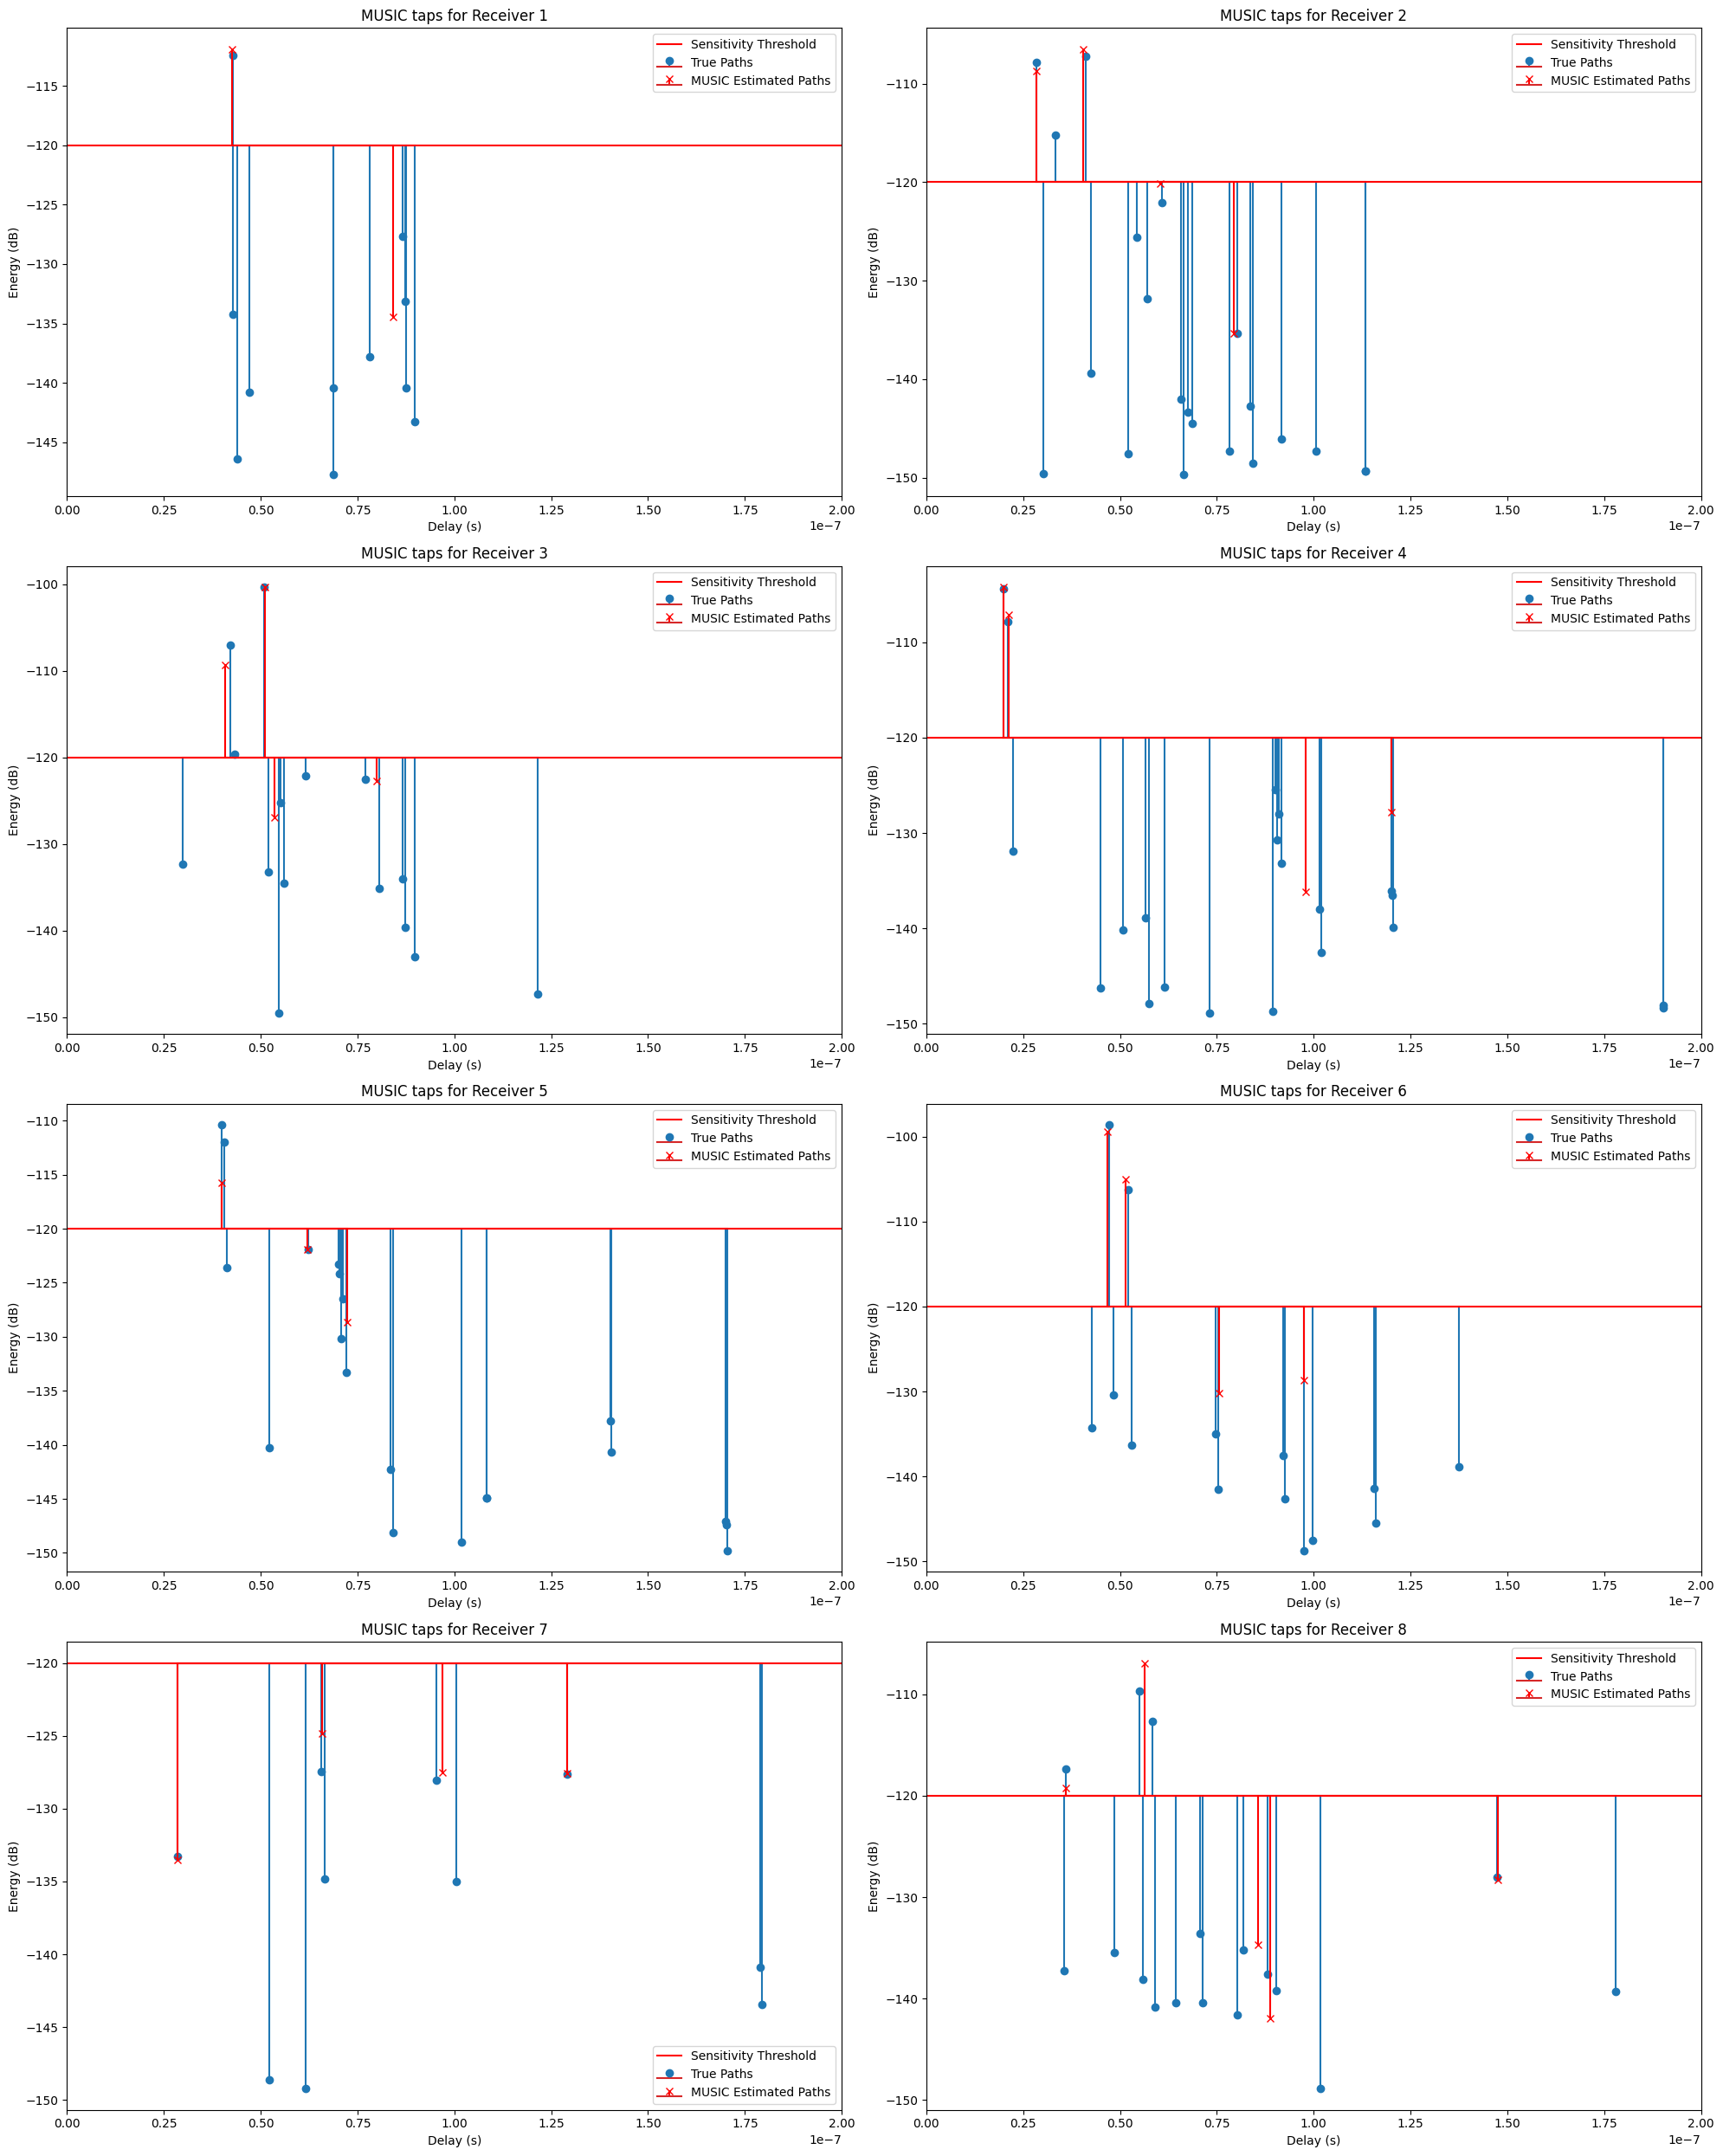

In [32]:
# Comparison of true vs estimated taps for one receiver
fig, ax = plt.subplots(4, 2, figsize=(20, 25))
for RX_idx in range(8):
    if len(music_taps_list[RX_idx]) > 0:
        ax[RX_idx//2, RX_idx%2].stem(tau[RX_idx], 10*np.log10(energies[RX_idx][0]), bottom=10*np.log10(S_RX_lin), label='True Paths')
        ax[RX_idx//2, RX_idx%2].stem(music_estimated_taus_list[RX_idx], 10*np.log10(np.abs(music_taps_list[RX_idx])**2), bottom=10*np.log10(S_RX_lin), linefmt='r-', markerfmt='rx', label='MUSIC Estimated Paths')
        ax[RX_idx//2, RX_idx%2].axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
        ax[RX_idx//2, RX_idx%2].set_title(f"MUSIC taps for Receiver {RX_idx+1}")
        ax[RX_idx//2, RX_idx%2].set_xlabel("Delay (s)")
        ax[RX_idx//2, RX_idx%2].set_ylabel("Energy (dB)")
        ax[RX_idx//2, RX_idx%2].set_xlim(0, 2e-7)
    ax[RX_idx//2, RX_idx%2].legend()
plt.tight_layout()
plt.show()


In [33]:
import Aoa
import Tdoa
import Hybrid
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)
importlib.reload(util)

true_first_toas = [tau[RX_idx][0] if len(tau[RX_idx]) > 0 else -1 for RX_idx in range(8)]
true_first_aoas = [angles[RX_idx][0] if len(angles[RX_idx]) > 0 else 4 for RX_idx in range(8)]

first_toas = np.zeros(8)
first_amplitudes = np.zeros(8, dtype=complex)
for RX_idx in range(8):
    first_toa = music_estimated_taus_list[RX_idx][0] if len(music_estimated_taus_list[RX_idx]) > 0 else -1
    first_toas[RX_idx] = first_toa
    first_amplitudes[RX_idx] = music_taps_list[RX_idx][0] if len(music_taps_list[RX_idx]) > 0 else 0

first_aoas = np.zeros(8)
for RX_idx in range(8):
    first_aoa = music_estimated_angles_list[RX_idx][0] if len(music_estimated_angles_list[RX_idx]) > 0 else 4
    # first_aoas.append(first_aoa)
    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])


# Manual correction of wrong estimates
# first_toas[1] = -1
# first_aoas[1] = 4
# first_toas[2] = -1
# first_aoas[2] = 4
# first_toas[5] = -1
# first_aoas[5] = 4
# first_toas[7] = -1
# first_aoas[7] = 4

# Shift or reference receiver
# first_toas[0], first_toas[2] = first_toas[2], first_toas[0]
# first_aoas[0], first_aoas[2] = first_aoas[2], first_aoas[0]



# for RX_idx in range(8):
#     print(f"Receiver {RX_idx+1}:")
#     print(f"  True First ToA: {true_first_toas[RX_idx]:.2e} s, Estimated First ToA: {first_toas[RX_idx]:.2e} s")
#     print(f"  True First AoA: {true_first_aoas[RX_idx]*180/np.pi:.2f} deg, Estimated First AoA: {first_aoas[RX_idx]*180/np.pi:.2f} deg")


# TDOA localization using first path
TdoaLocalizer = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas, first_amplitudes)
TdoaLocalizer2 = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas, first_amplitudes)
TdoaLocalizer3 = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas, first_amplitudes)
TdoaLocalizer4 = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas, first_amplitudes)

position_estimate_tdoa = TdoaLocalizer.localize()
position_estimate_tdoa2 = TdoaLocalizer2.localize_least_squares()
position_estimate_tdoa3, residuals_record = TdoaLocalizer3.localize_weighted_least_squares(iter=2)
position_estimate_tdoa4 = TdoaLocalizer4.localize_iterative_outlier_removal(iter=2)
print("TDOA Position Estimate:", position_estimate_tdoa)
print("TDOA Least Squares Position Estimate:", position_estimate_tdoa2)
print("TDOA Weighted Least Squares Position Estimate:", position_estimate_tdoa3)
print("TDOA Iterative Outlier Removal Position Estimate:", position_estimate_tdoa4)

# Filtering
errors = first_toas*3e8 - np.linalg.norm(np.array(RX_positions)[:,:2] - position_estimate_tdoa2, axis=1)
errors2 = TdoaLocalizer2.detect_outliers(position_estimate_tdoa2)
scores = TdoaLocalizer2.filter_receivers(position_estimate_tdoa2)
print("Receiver errors (m):", errors)
print("Receiver errors2 (m):", errors2)
print("Receiver scores:", scores)

# fig, ax = plt.subplots(1, residuals_record.shape[1], figsize=(20, 5))
# for i in range(residuals_record.shape[1]):
#     ax[i].plot(np.abs(residuals_record[:, i]))
#     ax[i].set_title(f"Residuals for TDoA {i+1}")
#     ax[i].set_xlabel("Iteration")
#     ax[i].set_ylabel("Residual (m)")
# plt.tight_layout()
# plt.show()

# for RX_idx in range(8):
#     print(f"Rx position: {RX_positions[RX_idx][:2]}")
#     print(f"Distance measured from toa: {first_toas[RX_idx]*3e8:.2f} m")
#     print(f"Actual distance from target: {np.linalg.norm(np.array(RX_positions[RX_idx][:2]) - np.array(TX_position[:2])):.2f} m")



# AOA localization using first path
AoaLocalizer = Aoa.AoaLocalization(first_aoas, [rx[:2] for rx in RX_positions])
position_estimate_aoa = AoaLocalizer.localize()
position_estimate_aoa2 = AoaLocalizer.localize_least_squares()
print("AOA Position Estimate:", position_estimate_aoa)
print("AOA Least Squares Position Estimate:", position_estimate_aoa2)

# Hybrid localization using tdoa and aoa
# HybridLocalizer = Hybrid.HybridLocalization(first_toas, first_aoas, [rx[:2] for rx in RX_positions])
# position_estimate_hybrid = HybridLocalizer.localize()
# print("Hybrid Position Estimate:", position_estimate_hybrid)

# print("True Transmitter Position:", tx.position)

Iteration 1, errors: [0.47714995 1.90491569 2.16659164 0.09017787 0.96022    0.85317493
 0.08839582 0.        ]
Iteration 2, errors: [0.15753856 0.6397238  0.4264846  0.43494229 1.01699796 0.73434189
 0.         0.        ]
TDOA Position Estimate: [2.06755173 0.1159722 ]
TDOA Least Squares Position Estimate: [1.84312566 0.22373741]
TDOA Weighted Least Squares Position Estimate: [1.99581733 0.06243805]
TDOA Iterative Outlier Removal Position Estimate: [2.99758166 0.7680981 ]
[True, True, True, True, True, True, False, False]
Receiver errors (m): [ 1.01692207  0.53682207  2.92146381 -1.15436471  1.10651824  1.97801462
  0.16083864  1.10394675]
Receiver errors2 (m): [0.47714995 1.90491569 2.16659164 0.09017787 0.96022    0.85317493
 0.08839582 0.        ]
Receiver scores: [2.48145156 2.2014658  1.92612864 1.39716139 0.97854017 0.86554912
 0.26614617 0.        ]
AOA Position Estimate: [ 3.07225585 -0.40349605]
AOA Least Squares Position Estimate: [ 3.07224298 -0.40351053]


In [ ]:
importlib.reload(Hybrid)
second_toas = np.zeros((8,1))
second_aoas = np.zeros((8,1))

for Rx_idx in range(8):
    if len(music_estimated_taus_list[Rx_idx]) > 1:
        second_toas[Rx_idx] = music_estimated_taus_list[Rx_idx][1]
    else:
        second_toas[Rx_idx] = -1
    
    if len(music_estimated_angles_list[Rx_idx]) > 1:
        second_aoas[Rx_idx] = util.global_angle(music_estimated_angles_list[Rx_idx][1], RX_orientations[Rx_idx])
    else:
        second_aoas[Rx_idx] = 4

print("Second ToAs:", second_toas.flatten())
print("Second AOAs:", second_aoas.flatten())

HybridLocalizer2 = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions],first_toas, first_aoas, first_amplitudes, second_toas, second_aoas, ref_index=0)
position_estimate_hybrid = HybridLocalizer2.localize()
position_estimate_hybrid_2 = HybridLocalizer2.localize2()
position_estimate_hybrid_time, t0 = HybridLocalizer2.localize_time()
position_estimate_hybrid_least_squares = HybridLocalizer2.localize_least_squares()
position_estimate_hybrid2 = HybridLocalizer2.localize_with_second()
position_estimate_hybrid3 = HybridLocalizer2.localize_iterative(max_iterations=5)
print("Hybrid Position Estimate with first paths only:", position_estimate_hybrid)
print("Hybrid Position Estimate with first paths only (method 2):", position_estimate_hybrid_2)
print("Hybrid Time-based Position Estimate:", position_estimate_hybrid_time, "with t0 =", t0)
print("Hybrid Least Squares Position Estimate with first paths only:", position_estimate_hybrid_least_squares)
print("Hybrid Position Estimate with second paths:", position_estimate_hybrid2)
print("Hybrid Position Estimate with iterative refinement:", position_estimate_hybrid3)

Second ToAs: [8.40840841e-08 4.04404404e-08 5.10510511e-08 2.12212212e-08
 6.20620621e-08 5.14514515e-08 6.58658659e-08 5.64564565e-08]
Second AOAs: [-1.1451895  -1.29875897 -2.59313025 -2.8695553  -0.83366286  0.86437675
  2.70282273  1.85599678]
Hybrid Position Estimate with first paths only: [2.44758241 0.0645735 ]
Hybrid Position Estimate with first paths only (method 2): [ 2.59959623 -0.23770495]
Hybrid Time-based Position Estimate: [ 2.77989831 -0.22060415] with t0 = 2.922696986109703e-09
Hybrid Time-based Position Estimate 2: [ 2.72682377 -0.22761111] with t0_2 = 2.7869375402413693e-09
Hybrid Least Squares Position Estimate with first paths only: [1.84312566 0.22373741]
Hybrid Position Estimate with second paths: [ 2.35934502 -0.43481123]
Hybrid Position Estimate with iterative refinement: [2.61092804 0.2552447 ]


In [35]:
c_0 = 299792458
t0_mean = 0
for RX_idx in range(8):
    if first_toas[RX_idx] > 0:
        t0_mean += first_toas[RX_idx] - np.linalg.norm(np.array(RX_positions[RX_idx][:2]) - position_estimate_hybrid_time) / c_0
t0_mean /= np.sum(first_toas > 0)
print("Mean t0 from all receivers:", t0_mean)

Mean t0 from all receivers: 2.7592892636167317e-09


In [36]:
importlib.reload(Tdoa)

TdoaLocalizer = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas, first_amplitudes)
position_estimate = TdoaLocalizer.localize_least_squares()

ratio = np.abs(first_amplitudes[0] / first_amplitudes[1:])
delta = np.array([tdoa.tdoa for tdoa in TdoaLocalizer.get_tdoas(0)]) * 3e8
distance = np.linalg.norm(np.array(RX_positions[0][:2]) - position_estimate)

# Taylor 1st order
for i in range(len(ratio)):
    m = - delta[i] / distance**2
    c = 1 + delta[i] / distance - ratio[i]
    x = -c / m

    print(f"Receiver {i+2}: ratio={ratio[i]:.4f}, delta={delta[i]:.2e}, distance={distance:.2e}")
    print(f"Receiver {i+2}: m={m:.2e}, c={c:.2e}, x={x:.2f} m")

# Taylor 2nd order
for i in range(len(ratio)):
    a = delta[i] / distance**3
    b = - delta[i] / distance**2
    c = 1 + delta[i] / distance - ratio[i]

    discriminant = b**2 - 4*a*c
    print(f"Receiver {i+2}: ratio={ratio[i]:.4f}, delta={delta[i]:.2e}, distance={distance:.2e}")
    print(f"Receiver {i+2}: a={a:.2e}, b={b:.2e}, c={c:.2e}, discriminant={discriminant:.2e}")
    x1 = (-b + np.sqrt(discriminant)) / (2*a)
    x2 = (-b - np.sqrt(discriminant)) / (2*a)

    print(f"Receiver {i+2}:")
    print(f"X1: {x1:.2f} m, X2: {x2:.2f} m")

Receiver 2: ratio=0.6928, delta=-4.26e+00, distance=1.18e+01
Receiver 2: m=3.08e-02, c=-5.49e-02, x=1.79 m
Receiver 3: ratio=0.7360, delta=-5.41e-01, distance=1.18e+01
Receiver 3: m=3.90e-03, c=2.18e-01, x=-55.95 m
Receiver 4: ratio=0.4118, delta=-6.79e+00, distance=1.18e+01
Receiver 4: m=4.89e-02, c=1.19e-02, x=-0.24 m
Receiver 5: ratio=1.5561, delta=-8.41e-01, distance=1.18e+01
Receiver 5: m=6.06e-03, c=-6.28e-01, x=103.49 m
Receiver 6: ratio=0.2378, delta=1.26e+00, distance=1.18e+01
Receiver 6: m=-9.10e-03, c=8.69e-01, x=95.57 m
Receiver 7: ratio=12.0112, delta=-4.20e+00, distance=1.18e+01
Receiver 7: m=3.03e-02, c=-1.14e+01, x=374.97 m
Receiver 8: ratio=2.3118, delta=-1.98e+00, distance=1.18e+01
Receiver 8: m=1.43e-02, c=-1.48e+00, x=103.56 m
Receiver 2: ratio=0.6928, delta=-4.26e+00, distance=1.18e+01
Receiver 2: a=-2.61e-03, b=3.08e-02, c=-5.49e-02, discriminant=3.72e-04
Receiver 2:
X1: 2.19 m, X2: 9.58 m
Receiver 3: ratio=0.7360, delta=-5.41e-01, distance=1.18e+01
Receiver 3: a=

C:\Users\louis\AppData\Local\Temp\ipykernel_19584\3437848104.py:28: RuntimeWarning: invalid value encountered in sqrt
  x1 = (-b + np.sqrt(discriminant)) / (2*a)
C:\Users\louis\AppData\Local\Temp\ipykernel_19584\3437848104.py:29: RuntimeWarning: invalid value encountered in sqrt
  x2 = (-b - np.sqrt(discriminant)) / (2*a)
